In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

In [22]:
# Load the dataset
df = pd.read_csv("../smoke_detection_iot.csv")

# Display the first 5 rows
df.head()



,Unnamed: 0,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
0,0,1654733331,20.000,57.36,0,400,12306,18520,939.735,0.0,0.0,0.0,0.0,0.0,0,0
1,1,1654733332,20.015,56.67,0,400,12345,18651,939.744,0.0,0.0,0.0,0.0,0.0,1,0
2,2,1654733333,20.029,55.96,0,400,12374,18764,939.738,0.0,0.0,0.0,0.0,0.0,2,0
3,3,1654733334,20.044,55.28,0,400,12390,18849,939.736,0.0,0.0,0.0,0.0,0.0,3,0
4,4,1654733335,20.059,54.69,0,400,12403,18921,939.744,0.0,0.0,0.0,0.0,0.0,4,0


In [27]:
# Features selected for our first ML model
features = [
    "Temperature[C]",
    "Humidity[%]",
    "TVOC[ppb]",
    "eCO2[ppm]",
    "PM2.5"
]

# Input features
X = df[features]

# Target
y = df["Fire Alarm"]

print("Selected features:")
for feature in features:
    print("-", feature)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Selected features:
- Temperature[C]
- Humidity[%]
- TVOC[ppb]
- eCO2[ppm]
- PM2.5

X shape: (62630, 5)
y shape: (62630,)


In [28]:
print(X.isnull().sum())
print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentages:")
print(y.value_counts(normalize=True) * 100)

Temperature[C]    0
Humidity[%]       0
TVOC[ppb]         0
eCO2[ppm]         0
PM2.5             0
dtype: int64

Target distribution:
Fire Alarm
1    44757
0    17873
Name: count, dtype: int64

Target percentages:
Fire Alarm
1    71.462558
0    28.537442
Name: proportion, dtype: float64


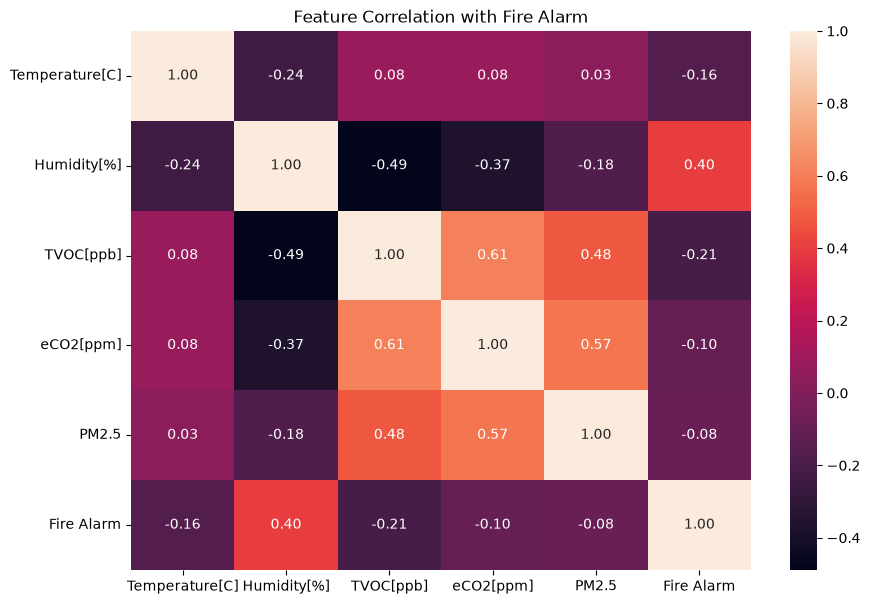

In [29]:
correlation = df[features + [target]].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(correlation, annot=True, fmt=".2f")
plt.title("Feature Correlation with Fire Alarm")
plt.show()

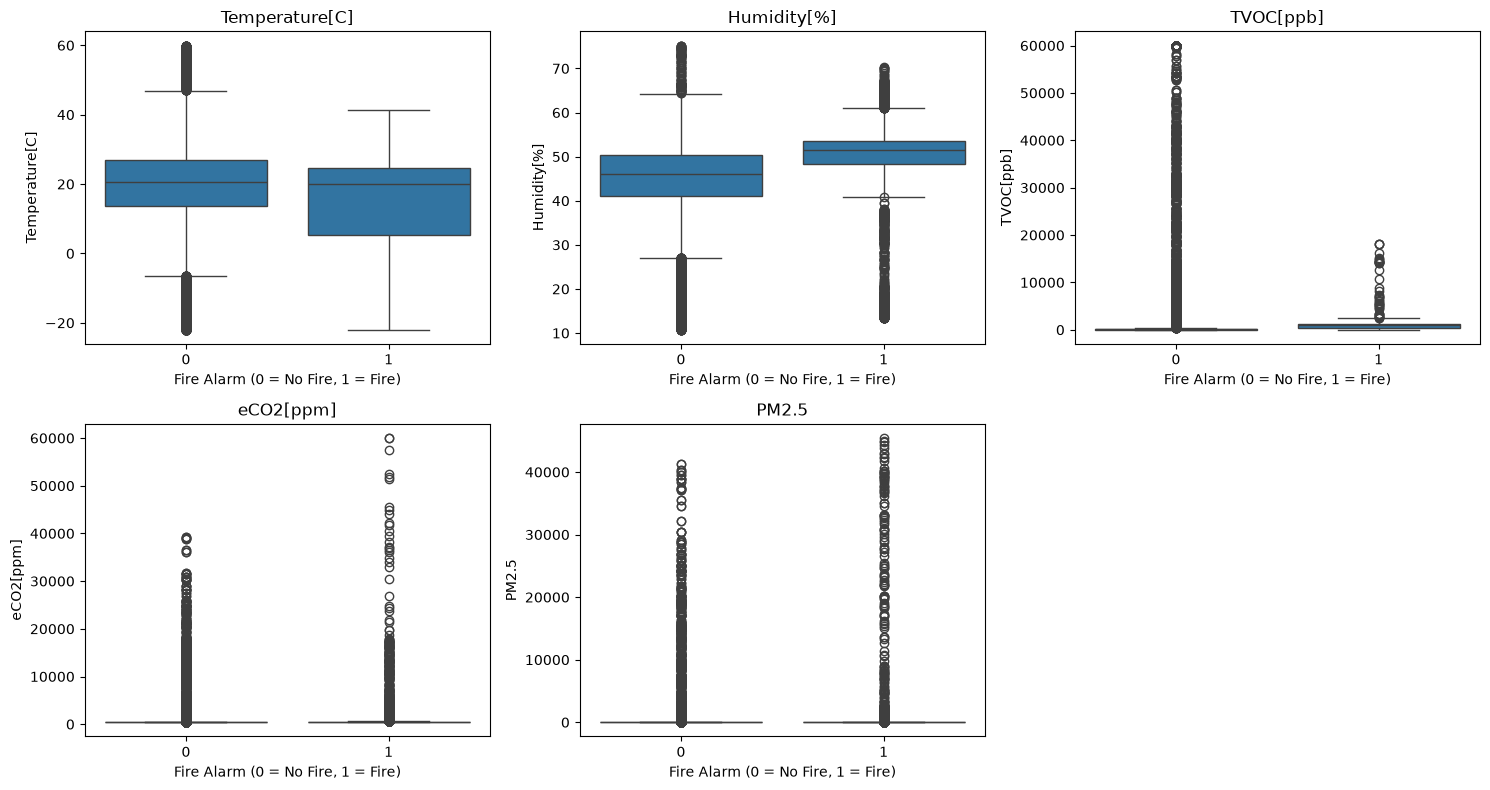

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, feature in enumerate(features):
    ax = axes.flat[i]
    
    sns.boxplot(
        data=df,
        x="Fire Alarm",
        y=feature,
        ax=ax
    )
    
    ax.set_title(feature)
    ax.set_xlabel("Fire Alarm (0 = No Fire, 1 = Fire)")

# Hide the unused sixth plot
axes.flat[5].set_visible(False)

plt.tight_layout()
plt.show()

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 50104
Testing samples: 12526


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [33]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [34]:
y_pred = model.predict(X_test_scaled)

print("Predictions completed!")
print("First 20 predictions:")
print(y_pred[:20])

Predictions completed!
First 20 predictions:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1]


In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 978 2597]
 [ 192 8759]]


In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# False Alarm Rate = FP / (FP + TN)
TN, FP, FN, TP = cm.ravel()
far = FP / (FP + TN)

print("Accuracy       :", round(accuracy, 4))
print("Precision      :", round(precision, 4))
print("Recall         :", round(recall, 4))
print("F1 Score       :", round(f1, 4))
print("False Alarm Rate:", round(far, 4))

Accuracy       : 0.7773
Precision      : 0.7713
Recall         : 0.9785
F1 Score       : 0.8627
False Alarm Rate: 0.7264
